In [4]:
import torch
import numpy as np
np.set_printoptions(precision=3)
a=[1,2,3]
b=np.array([4,5,6],dtype=np.int32)
t_a=torch.tensor(a)
t_b=torch.tensor(b)
print(t_a)
print(t_b)

tensor([1, 2, 3])
tensor([4, 5, 6], dtype=torch.int32)


In [5]:
t_ones = torch.ones(2, 3)
t_ones.shape

torch.Size([2, 3])

In [6]:
rand_tensor=torch.rand(2,3)
print(rand_tensor)

tensor([[0.6315, 0.5767, 0.4813],
        [0.2125, 0.8170, 0.9362]])


In [7]:
t_a_new=t_a.to(torch.int64)
print(t_a_new.dtype)

torch.int64


In [8]:
t = torch.rand(3, 5)
t_tr=torch.transpose(t,0,1)
print(t.shape, ' --> ', t_tr.shape)

torch.Size([3, 5])  -->  torch.Size([5, 3])


In [9]:
t = torch.zeros(30)
t_reshape = t.reshape(5, 6)
print(t_reshape.shape)

torch.Size([5, 6])


In [10]:
t=torch.zeros(1,2,1,4,1)
t_sqz=torch.squeeze(t,2)
print(t.shape, ' --> ', t_sqz.shape)

torch.Size([1, 2, 1, 4, 1])  -->  torch.Size([1, 2, 4, 1])


In [11]:
torch.manual_seed(1)
t1=2*torch.rand(5,2)-1
t2=torch.normal(mean=0,std=1,size=(5,2))
t3=torch.multiply(t1,t2)
t4=torch.mean(t1,axis=0)
print(t3)
print(t4)

tensor([[ 0.4426, -0.3114],
        [ 0.0660, -0.5970],
        [ 1.1249,  0.0150],
        [ 0.1569,  0.7107],
        [-0.0451, -0.0352]])
tensor([-0.1373,  0.2028])


In [12]:
from torch.utils.data import DataLoader
t=torch.arange(6,dtype=torch.float32)
data_loader=DataLoader(t)
for item in data_loader:
    print(item)

tensor([0.])
tensor([1.])
tensor([2.])
tensor([3.])
tensor([4.])
tensor([5.])


In [13]:
data_loader=DataLoader(t,batch_size=3,drop_last=False)
for i, batch in enumerate(data_loader, 1):
 print(f'batch {i}:', batch)

batch 1: tensor([0., 1., 2.])
batch 2: tensor([3., 4., 5.])


In [14]:
torch.manual_seed(1)
t_x = torch.rand([4, 3], dtype=torch.float32)
t_y = torch.arange(4)

In [15]:
from torch.utils.data import Dataset
class JointDataset(Dataset):
    def __init__(self,x,y):
        self.x=x
        self.y=y

    def __len__(self):
        return len(self.x) 

    def __getitem__(self,idx):
        return self.x[idx],self.y[idx]       

In [16]:
from torch.utils.data import TensorDataset
joint_dataset=TensorDataset(t_x,t_y)
for eg in joint_dataset:
 print('x: ', eg[0], 'y: ', eg[1])

x:  tensor([0.7576, 0.2793, 0.4031]) y:  tensor(0)
x:  tensor([0.7347, 0.0293, 0.7999]) y:  tensor(1)
x:  tensor([0.3971, 0.7544, 0.5695]) y:  tensor(2)
x:  tensor([0.4388, 0.6387, 0.5247]) y:  tensor(3)


In [17]:
import os
print(os.listdir('/media/WORK/CODING/rashcka_ml/celeba'))

['celeba', 'identity_CelebA.txt', 'img_align_celeba', 'list_attr_celeba.txt', 'list_bbox_celeba.txt', 'list_eval_partition.txt', 'list_landmarks_align_celeba.txt', 'list_landmarks_celeba.txt']


In [18]:
import torchvision
image_path = './'
celeba_dataset = torchvision.datasets.CelebA(image_path, split='train', target_type='attr', download=False )

In [19]:
assert isinstance(celeba_dataset,torch.utils.data.Dataset)

In [20]:
example=next(iter(celeba_dataset))
print(example)

(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=178x218 at 0x79B8770DB2F0>, tensor([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0,
        1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1]))


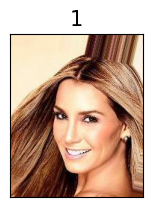

In [21]:
from itertools import islice
import matplotlib.pyplot as plt
fig=plt.figure(figsize=(12,8))
for i,(image,attributes) in islice(enumerate(celeba_dataset),18):
    ax=fig.add_subplot(3,6,i+1)
    ax.set_xticks([]);ax.set_yticks([])
    ax.imshow(image)
    ax.set_title(f'{attributes[31]}',size=15)
    plt.show()

In [22]:
mnist_dataset=torchvision.datasets.MNIST(image_path,'train',download=True)
assert isinstance(mnist_dataset,torch.utils.data.Dataset)
example=next(iter(mnist_dataset))
print(example)

100%|██████████| 9.91M/9.91M [00:19<00:00, 496kB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:04<00:00, 389kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.75MB/s]

(<PIL.Image.Image image mode=L size=28x28 at 0x79B871A227E0>, 5)


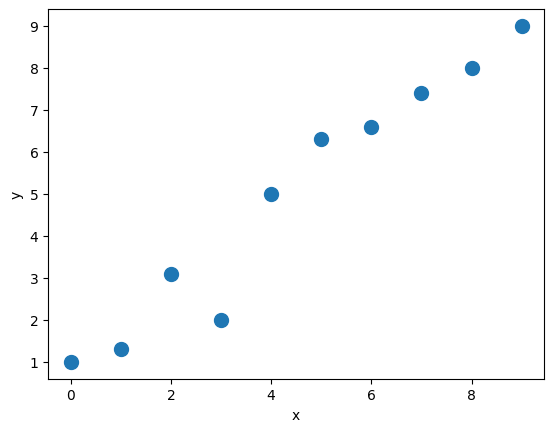

In [24]:
X_train=np.arange(10,dtype='float32').reshape((10,1))
y_train = np.array([1.0, 1.3, 3.1, 2.0, 5.0,6.3, 6.6,7.4, 8.0,9.0], dtype='float32')

plt.plot(X_train,y_train,'o',markersize=10)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [26]:
from torch.utils.data import TensorDataset
X_train_norm=(X_train-np.mean(X_train))/np.std(X_train)
X_train_norm=torch.from_numpy(X_train_norm)
y_train=torch.from_numpy(y_train).float()
train_ds=TensorDataset(X_train_norm,y_train)
batch_size=1
train_dl=DataLoader(train_ds,batch_size,shuffle=True)

In [27]:
torch.manual_seed(1)
weight=torch.randn(1)
weight.requires_grad_()
bias=torch.zeros(1,requires_grad=True)
def model(xb):
    return xb@weight +bias

def loss_fn(input,target):
    return (input-target).pow(2).mean()

In [30]:
learning_rate=0.001
num_epochs=200
log_epochs=10
for epoch in range(num_epochs):
    for x_batch,y_batch in train_dl:
        pred=model(x_batch)
        loss=loss_fn(pred,y_batch.long())
        loss.backward()
        with torch.no_grad():
            weight-=weight.grad*learning_rate
            bias -=bias.grad*learning_rate
            weight.grad.zero_()
            bias.grad.zero_()
        if epoch%log_epochs==0:
            print(f'Epoch {epoch} Loss{loss.item():.4f}')    

Epoch 0 Loss12.7852
Epoch 0 Loss5.4521
Epoch 0 Loss4.0431
Epoch 0 Loss25.9761
Epoch 0 Loss41.1253
Epoch 0 Loss51.2949
Epoch 0 Loss62.2846
Epoch 0 Loss30.9863
Epoch 0 Loss3.1594
Epoch 0 Loss33.5772
Epoch 10 Loss18.5525
Epoch 10 Loss34.4391
Epoch 10 Loss3.0240
Epoch 10 Loss27.0716
Epoch 10 Loss1.8687
Epoch 10 Loss20.6794
Epoch 10 Loss24.0109
Epoch 10 Loss2.6231
Epoch 10 Loss41.3476
Epoch 10 Loss8.9064
Epoch 20 Loss13.8461
Epoch 20 Loss2.2358
Epoch 20 Loss1.2055
Epoch 20 Loss17.4001
Epoch 20 Loss1.0250
Epoch 20 Loss28.2480
Epoch 20 Loss6.5010
Epoch 20 Loss22.5230
Epoch 20 Loss17.5737
Epoch 20 Loss12.9206
Epoch 30 Loss11.9767
Epoch 30 Loss9.6057
Epoch 30 Loss18.8667
Epoch 30 Loss0.4112
Epoch 30 Loss0.5600
Epoch 30 Loss12.4584
Epoch 30 Loss4.7737
Epoch 30 Loss8.7961
Epoch 30 Loss14.8259
Epoch 30 Loss1.6610
Epoch 40 Loss7.8847
Epoch 40 Loss7.0623
Epoch 40 Loss5.8229
Epoch 40 Loss1.2747
Epoch 40 Loss0.0696
Epoch 40 Loss9.1515
Epoch 40 Loss9.9903
Epoch 40 Loss12.4113
Epoch 40 Loss0.2560
Epoch 

In [34]:
import torch.nn as nn
loss_fn=nn.MSELoss(reduction='mean')
input_size=1
output_size=1
model=nn.Linear(input_size,output_size)
optimizer=torch.optim.SGD(model.parameters(),lr=learning_rate)

In [35]:
for epoch in range(num_epochs):
    for x_batch,y_batch in train_dl:
        pred=model(x_batch)[:,0]
        loss=loss_fn(pred,y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    if epoch%log_epochs==0:
        print(f'Epoch {epoch} Loss {loss.item():.4f}')    
print('Final Parameters:', model.weight.item(), model.bias.item())       

Epoch 0 Loss 40.5150
Epoch 10 Loss 1.9505
Epoch 20 Loss 1.4106
Epoch 30 Loss 8.9772
Epoch 40 Loss 10.1953
Epoch 50 Loss 6.1202
Epoch 60 Loss 5.5935
Epoch 70 Loss 0.4058
Epoch 80 Loss 0.3006
Epoch 90 Loss 0.2485
Epoch 100 Loss 0.6030
Epoch 110 Loss 0.7077
Epoch 120 Loss 0.8341
Epoch 130 Loss 0.4507
Epoch 140 Loss 0.1266
Epoch 150 Loss 0.1162
Epoch 160 Loss 1.1608
Epoch 170 Loss 0.0002
Epoch 180 Loss 0.0035
Epoch 190 Loss 2.1807
Final Parameters: 2.664569854736328 4.878113269805908


In [41]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
iris=load_iris()
X=iris['data']
y=iris['target']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=1./3,random_state=1)

In [42]:
print("X_train_norm shape:", X_train_norm.shape)
print("y_train shape:", y_train.shape)

X_train_norm shape: torch.Size([100, 4])
y_train shape: (100,)


In [43]:
X_train_norm =(X_train-np.mean(X_train))/np.std(X_train)
X_train_norm=torch.from_numpy(X_train_norm).float()
y_train=torch.from_numpy(y_train)
train_ds=TensorDataset(X_train_norm,y_train)
torch.manual_seed(1)
batch_size=2
train_dl=DataLoader(train_ds,batch_size,shuffle=True)

In [52]:
class Model(nn.Module):
    def __init__(self,input_size,hidden_size,output_size):
        super().__init__()
        self.layer1=nn.Linear(input_size,hidden_size)
        self.layer2=nn.Linear(hidden_size,output_size)

    def forward(self,x):
        x=self.layer1(x)
        x=nn.Sigmoid()(x)
        x=self.layer2(x)
        return x
input_size=X_train_norm.shape[1]
hidden_size=16
output_size=3 
model=Model(input_size,hidden_size,output_size)           

In [53]:
learning_rate=0.001
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)

In [54]:
num_epochs=100
loss_hist=[0]*num_epochs
accuracy_hist=[0]*num_epochs
for epoch in range(num_epochs):
    for x_batch,y_batch in train_dl:
        pred=model(x_batch)
        loss=loss_fn(pred,y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_hist[epoch]+=loss.item()*y_batch.size(0)
        is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
        accuracy_hist[epoch] += is_correct.sum()
    loss_hist[epoch] /= len(train_dl.dataset)    
    accuracy_hist[epoch] /= len(train_dl.dataset)

In [55]:
X_test_norm=(X_test-np.mean(X_train))/np.std(X_train)
X_test_norm=torch.from_numpy(X_test_norm).float()
y_test=torch.from_numpy(y_test)
pred_test=model(X_test_norm)
correct = (torch.argmax(pred_test, dim=1) == y_test).float()
accuracy=correct.mean()
print(f'Test Acc.: {accuracy:.4f}')

Test Acc.: 0.9800


In [56]:
path = 'iris_classifier.pt'
torch.save(model,path)

In [58]:
model_new=torch.load(path,weights_only=False)
model_new.eval()

Model(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=3, bias=True)
)

In [59]:
pred_test = model_new(X_test_norm)
correct=(torch.argmax(pred_test,dim=1)==y_test).float()
accuracy=correct.mean()
print(f'Test Acc.: {accuracy:.4f}')

Test Acc.: 0.9800


In [61]:
import numpy as np
X=np.array([1,1.4,2.5])
w=np.array([0.4,0.3,0.5])
def net_input(X,w):
    return np.dot(X,w)
def logistic(z):
    return 1.0/(1.0+np.exp(-z))
def logistic_activation(X,w):
    z=net_input(X,w)
    return logistic(z)
print(f'P(y=1|x) = {logistic_activation(X, w):.3f}')


P(y=1|x) = 0.888
